# Stock Price Movement Prediction Based on Tweet Sentiments

This notebook builds predictive models to forecast TSLA stock price movements between consecutive tweets.

**Approach**: For each tweet, we predict the stock price change from the time of that tweet until the next tweet.

## 1. Import Libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Load Data

In [81]:
# Load tweet sentiment data
tweets_df = pd.read_csv('../data/sanitized/tweets_with_sentiment.csv')
tweets_df['createdAt'] = pd.to_datetime(tweets_df['createdAt'])

# Load stock data
stock_df = pd.read_csv('../data/sanitized/TSLA_sanitized.csv')
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

print(f"Tweets: {len(tweets_df):,} rows")
print(f"Stock data: {len(stock_df):,} rows")
print(f"\nTweet date range: {tweets_df['createdAt'].min()} to {tweets_df['createdAt'].max()}")
print(f"Stock date range: {stock_df['Date'].min()} to {stock_df['Date'].max()}")

Tweets: 55,099 rows
Stock data: 3,680 rows

Tweet date range: 2010-06-04 18:31:57+00:00 to 2025-04-13 21:28:44+00:00
Stock date range: 2010-06-29 00:00:00 to 2025-02-12 00:00:00


## 3. Data Preparation & Feature Engineering

In [82]:
# Sort tweets by time
tweets_df = tweets_df.sort_values('createdAt').reset_index(drop=True)

# Extract date for merging with stock data
tweets_df['date'] = tweets_df['createdAt'].dt.date
stock_df['date'] = stock_df['Date'].dt.date

# Create a function to get stock price at a specific datetime
def get_stock_price_on_date(date, stock_data):
    """
    Get closing price for a given date. If market is closed, use the most recent prior closing price.
    """
    stock_on_date = stock_data[stock_data['date'] == date]
    if len(stock_on_date) > 0:
        return stock_on_date.iloc[0]['Close']
    else:
        # Market was closed - find the most recent previous trading day
        prior_dates = stock_data[stock_data['date'] < date]
        if len(prior_dates) > 0:
            return prior_dates.iloc[-1]['Close']
        else:
            return np.nan

print("Getting stock prices for each tweet date...")
tweets_df['stock_price'] = tweets_df['date'].apply(lambda x: get_stock_price_on_date(x, stock_df))

print(f"Tweets with valid stock prices: {tweets_df['stock_price'].notna().sum():,}")

Getting stock prices for each tweet date...
Tweets with valid stock prices: 55,098


In [83]:
# Calculate time and price change to next tweet
tweets_df['next_tweet_time'] = tweets_df['createdAt'].shift(-1)
tweets_df['next_tweet_price'] = tweets_df['stock_price'].shift(-1)

# Calculate changes
tweets_df['time_to_next_tweet_hours'] = (
    tweets_df['next_tweet_time'] - tweets_df['createdAt']
).dt.total_seconds() / 3600

tweets_df['price_change'] = tweets_df['next_tweet_price'] - tweets_df['stock_price']
tweets_df['price_change_pct'] = (
    (tweets_df['next_tweet_price'] - tweets_df['stock_price']) / tweets_df['stock_price'] * 100
)

# Create binary target: 1 if price went up, 0 if down
tweets_df['price_went_up'] = (tweets_df['price_change'] > 0).astype(int)

# Remove last row (no next tweet)
tweets_df = tweets_df[:-1]

print(f"\nTime between tweets (hours):")
print(tweets_df['time_to_next_tweet_hours'].describe())
print(f"\nPrice change percentage:")
print(tweets_df['price_change_pct'].describe())


Time between tweets (hours):
count    55098.000000
mean         2.363987
std         56.705768
min          0.000000
25%          0.033889
50%          0.106667
75%          0.580000
max      13071.387222
Name: time_to_next_tweet_hours, dtype: float64

Price change percentage:
count    55097.000000
mean         0.012977
std          0.877699
min        -21.062824
25%          0.000000
50%          0.000000
75%          0.000000
max         24.395076
Name: price_change_pct, dtype: float64


In [84]:
# Feature engineering - create meaningful features from tweet data

# Fill missing sentiment scores with neutral values
tweets_df['vader_compound'] = tweets_df['vader_compound'].fillna(0)
tweets_df['vader_pos'] = tweets_df['vader_pos'].fillna(0.5)
tweets_df['vader_neg'] = tweets_df['vader_neg'].fillna(0.5)
tweets_df['vader_neu'] = tweets_df['vader_neu'].fillna(0.5)

# Encode market timing
tweets_df['is_market_hours'] = (tweets_df['market_timing'] == 'Market hours').astype(int)
tweets_df['is_pre_market'] = (tweets_df['market_timing'] == 'Pre-market').astype(int)
tweets_df['is_after_market'] = (tweets_df['market_timing'] == 'After-market').astype(int)

# Engagement features (normalized by log to handle extreme values)
tweets_df['likeCount'] = tweets_df['likeCount'].fillna(0)
tweets_df['retweetCount'] = tweets_df['retweetCount'].fillna(0)
tweets_df['replyCount'] = tweets_df['replyCount'].fillna(0)
tweets_df['viewCount'] = tweets_df['viewCount'].fillna(0)

tweets_df['log_likes'] = np.log1p(tweets_df['likeCount'])
tweets_df['log_retweets'] = np.log1p(tweets_df['retweetCount'])
tweets_df['log_replies'] = np.log1p(tweets_df['replyCount'])
tweets_df['log_views'] = np.log1p(tweets_df['viewCount'])

# Total engagement score
tweets_df['total_engagement'] = (
    tweets_df['likeCount'] + 
    tweets_df['retweetCount'] * 2 +  # Retweets weighted higher
    tweets_df['replyCount'] + 
    tweets_df['viewCount'] * 0.001  # Views weighted less
)
tweets_df['log_total_engagement'] = np.log1p(tweets_df['total_engagement'])

# Time-based features
tweets_df['hour'] = tweets_df['createdAt'].dt.hour
tweets_df['day_of_week'] = tweets_df['createdAt'].dt.dayofweek
tweets_df['month'] = tweets_df['createdAt'].dt.month
tweets_df['year'] = tweets_df['createdAt'].dt.year

print("Feature engineering complete!")
print(f"\nTotal features available: {len(tweets_df.columns)}")

Feature engineering complete!

Total features available: 38


## 4. Exploratory Data Analysis

In [85]:
# Remove rows with missing target or key features
model_df = tweets_df.dropna(subset=['price_change', 'vader_compound', 'stock_price']).copy()

print(f"Dataset for modeling: {len(model_df):,} tweets")
print(f"\nPrice went up: {model_df['price_went_up'].sum():,} ({model_df['price_went_up'].mean()*100:.1f}%)")
print(f"Price went down: {(1-model_df['price_went_up']).sum():,} ({(1-model_df['price_went_up'].mean())*100:.1f}%)")

Dataset for modeling: 55,097 tweets

Price went up: 1,313 (2.4%)
Price went down: 53,784 (97.6%)


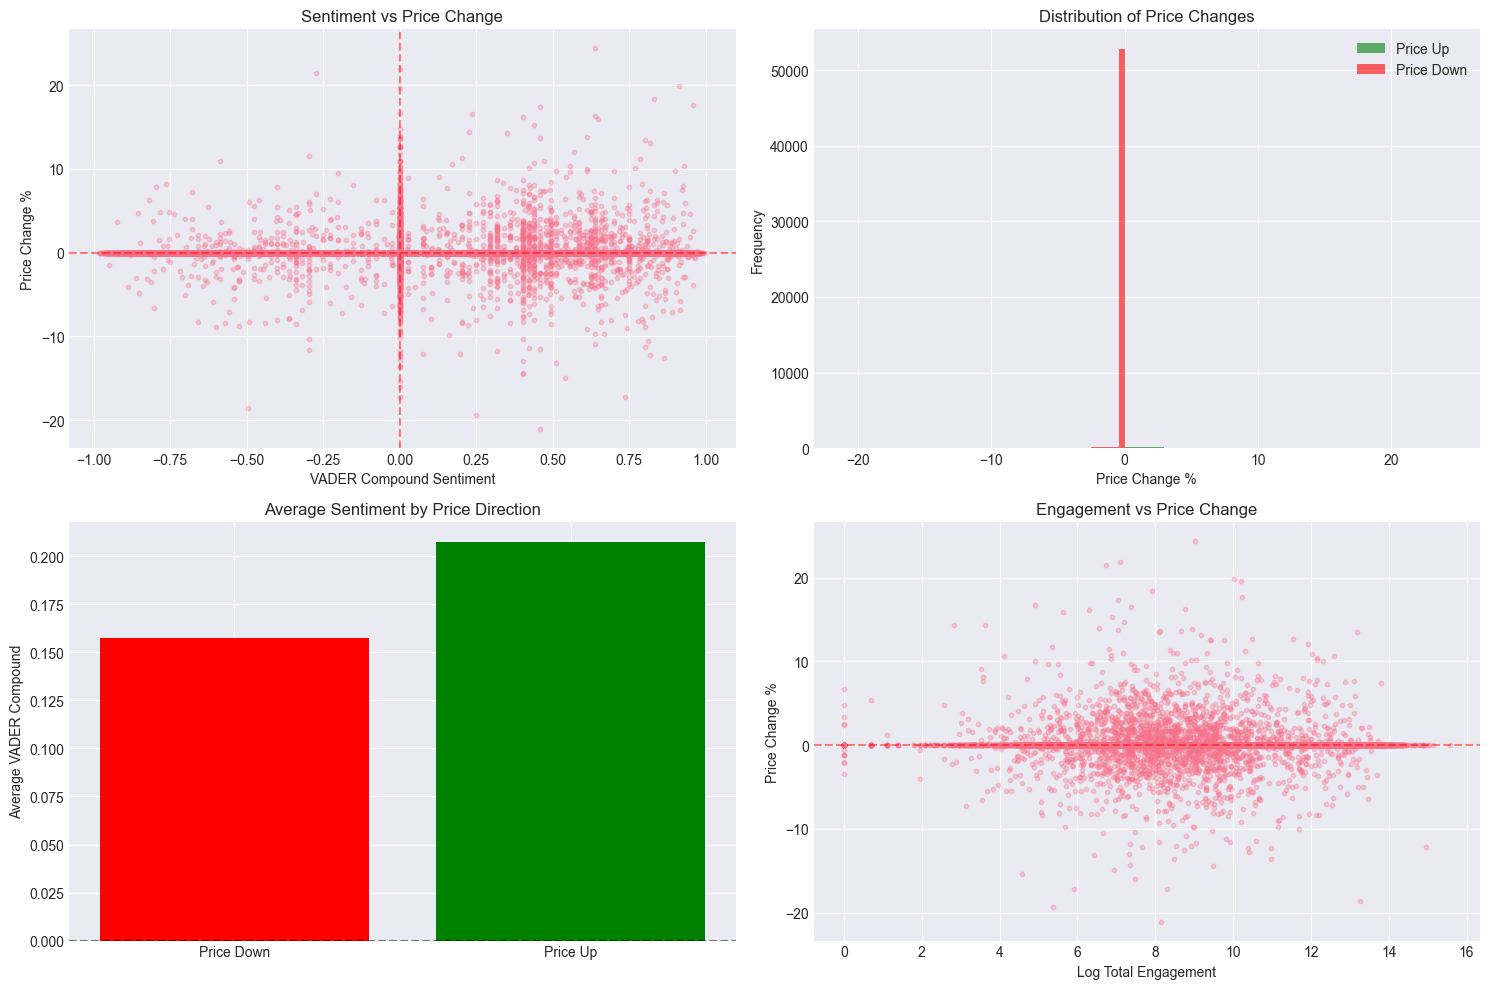

In [86]:
# Visualize relationship between sentiment and price movement
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Sentiment vs Price Change
axes[0, 0].scatter(model_df['vader_compound'], model_df['price_change_pct'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('VADER Compound Sentiment')
axes[0, 0].set_ylabel('Price Change %')
axes[0, 0].set_title('Sentiment vs Price Change')
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 0].axvline(x=0, color='r', linestyle='--', alpha=0.5)

# 2. Distribution of price changes by direction
model_df[model_df['price_went_up'] == 1]['price_change_pct'].hist(
    bins=50, alpha=0.6, label='Price Up', ax=axes[0, 1], color='green'
)
model_df[model_df['price_went_up'] == 0]['price_change_pct'].hist(
    bins=50, alpha=0.6, label='Price Down', ax=axes[0, 1], color='red'
)
axes[0, 1].set_xlabel('Price Change %')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Price Changes')
axes[0, 1].legend()

# 3. Average sentiment by price direction
sentiment_by_direction = model_df.groupby('price_went_up')['vader_compound'].mean()
axes[1, 0].bar(['Price Down', 'Price Up'], sentiment_by_direction.values, color=['red', 'green'])
axes[1, 0].set_ylabel('Average VADER Compound')
axes[1, 0].set_title('Average Sentiment by Price Direction')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)

# 4. Engagement vs Price Change
axes[1, 1].scatter(model_df['log_total_engagement'], model_df['price_change_pct'], alpha=0.3, s=10)
axes[1, 1].set_xlabel('Log Total Engagement')
axes[1, 1].set_ylabel('Price Change %')
axes[1, 1].set_title('Engagement vs Price Change')
axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

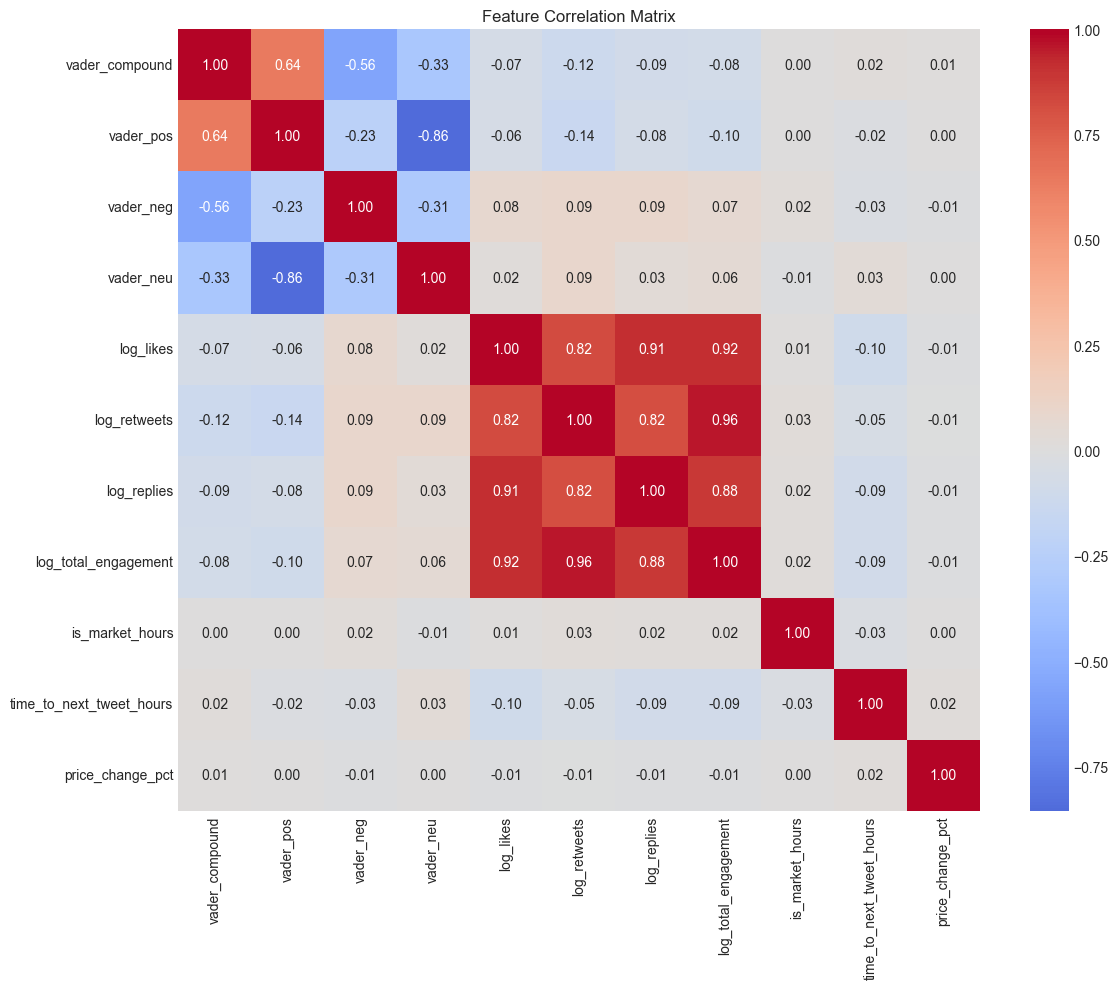


Correlation with price_change_pct:
price_change_pct            1.000000
time_to_next_tweet_hours    0.020795
vader_compound              0.008862
vader_neu                   0.003878
is_market_hours             0.001574
vader_pos                   0.000619
log_retweets               -0.006821
vader_neg                  -0.008446
log_replies                -0.009110
log_total_engagement       -0.009123
log_likes                  -0.010236
Name: price_change_pct, dtype: float64


In [87]:
# Correlation analysis
correlation_features = [
    'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu',
    'log_likes', 'log_retweets', 'log_replies', 'log_total_engagement',
    'is_market_hours', 'time_to_next_tweet_hours', 'price_change_pct'
]

correlation_matrix = model_df[correlation_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelation with price_change_pct:")
print(correlation_matrix['price_change_pct'].sort_values(ascending=False))

## 5. Prepare Data for Modeling

In [88]:
# Select features for modeling
feature_columns = [
    # Sentiment features
    'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu',
    
    # Engagement features
    'log_likes', 'log_retweets', 'log_replies', 'log_views', 'log_total_engagement',
    
    # Market timing
    'is_market_hours', 'is_pre_market', 'is_after_market',
    
    # Time features
    'hour', 'day_of_week', 'month',
    
    # Context
    'time_to_next_tweet_hours'
]

X = model_df[feature_columns].copy()
y_classification = model_df['price_went_up'].copy()  # Binary: up or down
y_regression = model_df['price_change_pct'].copy()   # Actual percentage change

# Use time-based split (important for time series data!)
# Use 80% for training, 20% for testing
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train_class = y_classification.iloc[:split_idx]
y_test_class = y_classification.iloc[split_idx:]
y_train_reg = y_regression.iloc[:split_idx]
y_test_reg = y_regression.iloc[split_idx:]

print(f"Training set: {len(X_train):,} samples")
print(f"Testing set: {len(X_test):,} samples")
print(f"\nTraining date range: {model_df.iloc[:split_idx]['createdAt'].min()} to {model_df.iloc[:split_idx]['createdAt'].max()}")
print(f"Testing date range: {model_df.iloc[split_idx:]['createdAt'].min()} to {model_df.iloc[split_idx:]['createdAt'].max()}")

Training set: 44,077 samples
Testing set: 11,020 samples

Training date range: 2011-12-01 09:55:11+00:00 to 2024-10-28 22:05:51+00:00
Testing date range: 2024-10-28 22:07:06+00:00 to 2025-04-13 21:27:08+00:00


In [89]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled!")

Features scaled!


## 6. Classification Models (Predict Direction: Up or Down)

In [90]:
# Baseline: What if we always predicted the majority class?
baseline_accuracy = y_test_class.mean() if y_test_class.mean() > 0.5 else 1 - y_test_class.mean()
print(f"Baseline accuracy (always predict majority): {baseline_accuracy:.2%}")


Baseline accuracy (always predict majority): 99.69%


### 6.1 Logistic Regression

LOGISTIC REGRESSION RESULTS

Accuracy: 99.69%

Classification Report:
              precision    recall  f1-score   support

        Down       1.00      1.00      1.00     10986
          Up       0.00      0.00      0.00        34

    accuracy                           1.00     11020
   macro avg       0.50      0.50      0.50     11020
weighted avg       0.99      1.00      1.00     11020



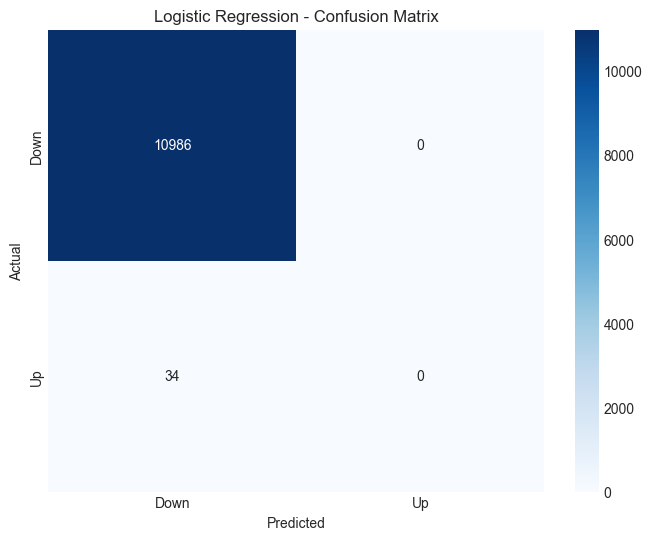


Top 10 Most Important Features:
                     feature  coefficient
12                      hour     1.346699
15  time_to_next_tweet_hours     0.614119
9            is_market_hours    -0.601716
7                  log_views    -0.601148
13               day_of_week    -0.353642
11           is_after_market    -0.309567
10             is_pre_market    -0.211262
6                log_replies     0.109903
4                  log_likes    -0.095933
5               log_retweets     0.061406


In [91]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_class)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test_class, y_pred_lr):.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test_class, y_pred_lr, target_names=['Down', 'Up']))

# Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

**LOGISTIC REGRESSION**

The 99.69% accuracy is **misleading** due to severe class imbalance:
- The model predicts "Down" for ALL cases (see confusion matrix: 0 "Up" predictions)
- Precision/Recall for "Up" = 0% → The model learned nothing about sentiment
- **Why this happened**: 99.69% of test cases are "Down", so always predicting "Down" = 99.69% accuracy
- **Conclusion**: This model is useless for trading - it never identifies upward movements

## 7. Regression Models (Predict Magnitude of Change)

### 7.1 Linear Regression

LINEAR REGRESSION RESULTS

Mean Absolute Error: 0.0372%
Root Mean Squared Error: 0.3418%
R² Score: -0.0034


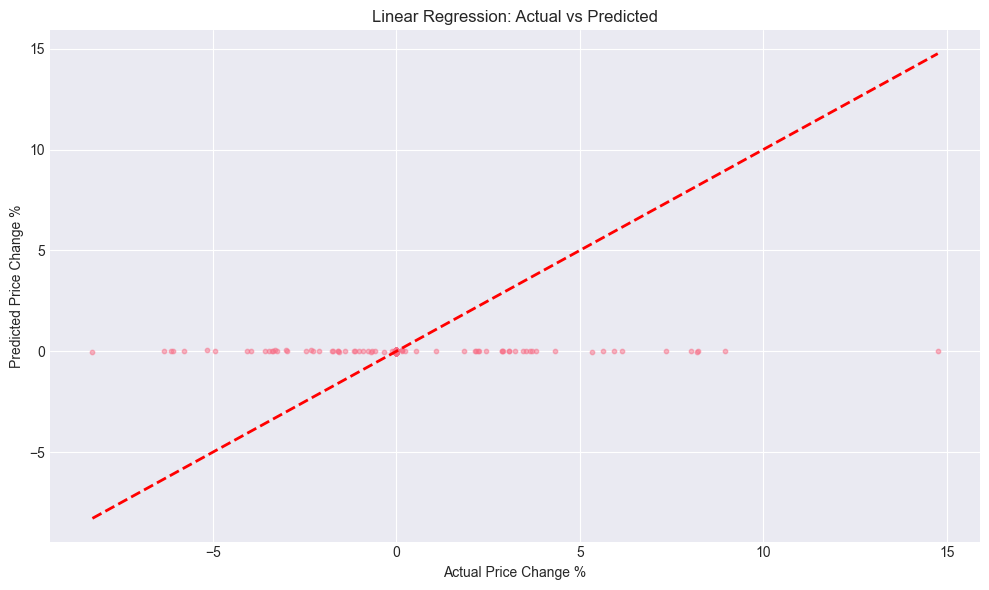

In [92]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)

y_pred_lin = lin_reg.predict(X_test_scaled)

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"\nMean Absolute Error: {mean_absolute_error(y_test_reg, y_pred_lin):.4f}%")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test_reg, y_pred_lin)):.4f}%")
print(f"R² Score: {r2_score(y_test_reg, y_pred_lin):.4f}")

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_lin, alpha=0.5, s=10)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Price Change %')
plt.ylabel('Predicted Price Change %')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

**Analysis: LINEAR REGRESSION COMPLETELY FAILED**

- **R² Score: -0.0034** → Negative R² means the model is WORSE than just predicting the average!
- MAE: 0.037% (seems small, but meaningless given R²)
- **Scatter plot shows**: Model predicts ~0% change for almost everything (flat horizontal line)
- **Why negative R²**: Model's predictions are less accurate than a horizontal line at the mean
- **Conclusion**: Tweet sentiment features have NO linear relationship with price changes

## 8. Model Comparison & Final Insights

In [93]:
# Compare all classification models
classification_results = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression'],
    'Accuracy': [
        baseline_accuracy,
        accuracy_score(y_test_class, y_pred_lr),
    ]
})

print(classification_results.to_string(index=False))

              Model  Accuracy
           Baseline  0.996915
Logistic Regression  0.996915


## Conclusions

### 1. **99.69% Class Imbalance**

- Test set composition: 10,986 "Down" vs. only 34 "Up"
- Since I'm using only daily closing prices, stock price between tweets only changes when a trading day passes, which I thought would have a strong correlation with tweets, but most consecutive tweets happen within hours on the same day, which leads into the next point.

### 2. **Tweet-to-Tweet is Wrong Window**

- Time between tweets varies wildly (minutes to weeks)
- Inconsistent prediction horizon makes learning impossible
- Better: Fixed forward windows (1-day, 2-day, 7-day)

### 3. **Sentiment Features Insufficient**

- VADER sentiment alone doesn't capture market context
- Need the assistance of technical indicators (RSI, Bollinger Bands, MACD)
- Need engagement quality metrics